imports

In [2]:
import importlib
import numpy as np
import pandas as pd
import os
from datetime import datetime
import json

import load_data
import assign_labels
import build_features
import train
import plots
import extract_ontology
import build_topology_graph
import build_ontology
import symbolic_features
import metrics
import experiment

importlib.reload(load_data)
importlib.reload(assign_labels)
importlib.reload(build_features)
importlib.reload(train)
importlib.reload(plots)
importlib.reload(extract_ontology)
importlib.reload(build_topology_graph)
importlib.reload(build_ontology)
importlib.reload(symbolic_features)
importlib.reload(metrics)
importlib.reload(experiment)

from load_data import load_alerts_from_json
from assign_labels import add_labels_to_df
from build_features import build_dyn_features, build_static_features
from symbolic_features import build_symbolic_features
from train import *
from plots import *
from extract_ontology import topology_edges, host_sets
from build_topology_graph import plot_scenario_topologies
from build_ontology import build_all_scenarios
from metrics import eval_subset_metrics
from experiment import run_experiment, make_time_windows, run_windowed_symbolic_pipeline

### Load data
##### Wazuh + Aminer Alerts (AIT-ADS, .json format) to .csv

In [ ]:
output_file = "combined_ait.csv"
dir_path = "../data/ait_ads"

df = load_alerts_from_json(output_file, dir_path)

Opening file ../data/ait_ads/harrison_aminer.json...
Opening file ../data/ait_ads/wardbeck_wazuh.json...
Opening file ../data/ait_ads/wheeler_wazuh.json...
Opening file ../data/ait_ads/shaw_wazuh.json...
Opening file ../data/ait_ads/wilson_aminer.json...
Opening file ../data/ait_ads/fox_aminer.json...
Opening file ../data/ait_ads/santos_wazuh.json...
Opening file ../data/ait_ads/fox_wazuh.json...
Opening file ../data/ait_ads/shaw_aminer.json...
Opening file ../data/ait_ads/wheeler_aminer.json...
Opening file ../data/ait_ads/russellmitchell_aminer.json...
Opening file ../data/ait_ads/harrison_wazuh.json...
Opening file ../data/ait_ads/wilson_wazuh.json...
Opening file ../data/ait_ads/santos_aminer.json...
Opening file ../data/ait_ads/russellmitchell_wazuh.json...
Opening file ../data/ait_ads/wardbeck_aminer.json...
Writing data to combined_ait.csv...

...
Done.


: 

##### Load .csv to notebook

In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait.csv")
df.head()
print(df["timestamp"].min(), df["timestamp"].max())
df["timestamp"].map(type).value_counts()

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_3174/912057347.py:1: DtypeWarning: Columns (7,10,12,13,14,17,24,31,32,36,37,38,39,40,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait.csv")


2022-01-14 00:00:01.750000+00:00 2022-02-08 23:59:46.130000114+00:00


timestamp
<class 'str'>    2655821
Name: count, dtype: int64

: 

#### Sanity checks

In [ ]:
df.columns

Index(['timestamp', 'category', 'entity', 'raw_log', 'scenario', 'source',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'groups_raw',
       'groups_str', 'srcip', 'dstip', 'srcport', 'dstport', 'proto',
       'is_auth_event', 'is_cred_event', 'is_web_event', 'is_cron',
       'is_success', 'is_uid0', 'aminer_component_type',
       'aminer_training_mode', 'aminer_new_event', 'wazuh_level',
       'wazuh_antivirus', 'wazuh_update', 'is_ids_alert', 'ids_signature',
       'ids_category', 'ids_severity', 'exploit_class', 'alert_channel',
       'decoder', 'decoder_parent', 'location', 'mitre_ids', 'mitre_tactic',
       'mitre_technique', 'username', 'procname'],
      dtype='object')

: 

In [ ]:
df[df["rule_desc"]=="IDS event."][["ids_signature","ids_category","ids_severity","proto","srcip","dstip","dstport","exploit_class"]].head(5)

,ids_signature,ids_category,ids_severity,proto,srcip,dstip,dstport,exploit_class
10204,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.95.85,80.0,policy_indicator
10206,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10207,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10210,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.88.152,80.0,policy_indicator
10211,ET POLICY GNU/Linux APT User-Agent Outbound li...,Not Suspicious Traffic,3.0,TCP,192.168.96.4,91.189.91.39,80.0,policy_indicator


: 

In [ ]:
df["exploit_class"].value_counts().head(20)

exploit_class
unknown             1913052
tls_fingerprint      420465
dns_suspicious       184831
rce                  121828
malware                8407
policy_indicator       7120
bruteforce_auth          90
ids_policy_info          24
recon_scan                4
Name: count, dtype: int64

: 

In [ ]:
df[df["ids_signature"].notna()]["exploit_class"].value_counts().head(20)


exploit_class
tls_fingerprint     420465
dns_suspicious      184831
policy_indicator      7120
unknown                914
ids_policy_info         24
recon_scan               4
Name: count, dtype: int64

: 

In [ ]:
df[df["scenario"] == "shaw"]["exploit_class"].value_counts()

exploit_class
unknown             35717
tls_fingerprint     32128
malware              1291
policy_indicator     1032
rce                   378
dns_suspicious        228
bruteforce_auth         4
recon_scan              4
Name: count, dtype: int64

: 

In [ ]:
df[df["scenario"] == "shaw"][["srcip","dstip"]].dropna().shape

(33634, 2)

: 

In [ ]:
df["ids_category"].value_counts().sort_index()

ids_category
(null)                                  3
Attempted User Privilege Gain          24
Generic Protocol Command Decode    421175
Misc activity                           4
Not Suspicious Traffic               6844
Potentially Bad Traffic            185029
Web Application Attack                276
Name: count, dtype: int64

: 

#### Topology + ontology

In [ ]:
edge_table = topology_edges(df, min_weight=3)
edge_table.head(10)

,scenario,srcip,dstip,proto,dstport,weight
0,fox,10.35.33.111,91.189.88.142,TCP,80.0,28
1,fox,10.35.33.111,91.189.88.152,TCP,80.0,16
2,fox,10.35.33.111,91.189.91.38,TCP,80.0,6
4,fox,10.35.33.111,91.189.95.85,TCP,80.0,10
5,fox,10.35.35.206,91.189.88.142,TCP,80.0,16
6,fox,10.35.35.206,91.189.88.152,TCP,80.0,24
8,fox,10.35.35.206,91.189.91.39,TCP,80.0,8
9,fox,10.35.35.206,91.189.95.85,TCP,80.0,10
10,fox,100.21.15.207,192.168.128.4,TCP,49634.0,4
11,fox,100.24.82.208,192.168.128.4,TCP,58058.0,4


: 

In [ ]:
host_summary = host_sets(df, edge_table)
host_summary

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/extract_ontology.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: set(g["srcip"]).union(set(g["dstip"])))


,scenario,n_active_hosts,n_hosts_in_edges,isolated_but_active
0,fox,13,889,6
1,harrison,11,951,3
2,russellmitchell,11,634,3
3,santos,11,1212,3
4,shaw,12,1094,10
5,wardbeck,12,1409,4
6,wheeler,13,1448,5
7,wilson,11,1461,3


: 

In [ ]:
scenarios = sorted(edge_table["scenario"].unique())

for sc in scenarios:
    plot_scenario_topologies(edge_table, sc, out_dir="../out/topologies/", collapse=True, min_weight=10, remove_hubs_k=3, make_subnet_view=True, subnet_k=3)

: 

In [ ]:
build_all_scenarios("../out/ontology_inputs/scenario_hosts.csv",
                    "../out/ontology_inputs/scenario_services.csv",
                    "../out/ontology_inputs/scenario_edges.csv",
                    "../data/ait_ads/combined_ait.csv",
                    out_dir="../out/ontology_out",
                    k=3)

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/build_ontology.py:156: DtypeWarning: Columns (7,10,11,12,15,22,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  alerts_df = pd.read_csv(alerts_csv)


Wrote ../out/ontology_out/ontology_fox.ttl
Wrote ../out/ontology_out/ontology_harrison.ttl
Wrote ../out/ontology_out/ontology_russellmitchell.ttl
Wrote ../out/ontology_out/ontology_santos.ttl
Wrote ../out/ontology_out/ontology_shaw.ttl
Wrote ../out/ontology_out/ontology_wardbeck.ttl
Wrote ../out/ontology_out/ontology_wheeler.ttl
Wrote ../out/ontology_out/ontology_wilson.ttl


: 

## Labelling

In [ ]:
add_labels_to_df(df)

event_label
benign    2509439
attack     146382
Name: count, dtype: int64
scenario         event_label
fox              benign         441601
                 attack          31503
harrison         benign         561805
                 attack          32143
russellmitchell  benign          39089
                 attack           6455
santos           benign         123766
                 attack           7013
shaw             benign          69009
                 attack           1773
wardbeck         benign          89296
                 attack           1961
wheeler          benign         580288
                 attack          35873
wilson           benign         604585
                 attack          29661
Name: count, dtype: int64
Writing to output file...
Done.


: 

In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")

# print columns
df.columns


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_67232/1745759900.py:1: DtypeWarning: Columns (7,10,12,13,14,17,24,31,32,36,37,38,39,40,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv")


Index(['timestamp', 'category', 'entity', 'raw_log', 'scenario', 'source',
       'host_ip', 'host', 'rule_id', 'rule_desc', 'groups', 'groups_raw',
       'groups_str', 'srcip', 'dstip', 'srcport', 'dstport', 'proto',
       'is_auth_event', 'is_cred_event', 'is_web_event', 'is_cron',
       'is_success', 'is_uid0', 'aminer_component_type',
       'aminer_training_mode', 'aminer_new_event', 'wazuh_level',
       'wazuh_antivirus', 'wazuh_update', 'is_ids_alert', 'ids_signature',
       'ids_category', 'ids_severity', 'exploit_class', 'alert_channel',
       'decoder', 'decoder_parent', 'location', 'mitre_ids', 'mitre_tactic',
       'mitre_technique', 'username', 'procname', 'event_label', 'y'],
      dtype='object')

: 

In [13]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

for scenario, df_s in df.groupby("scenario"):
    t_min = df_s["timestamp"].min()
    t_max = df_s["timestamp"].max()
    delta = t_max - t_min

    days = delta.days
    hours = delta.total_seconds() / 3600
    minutes = delta.total_seconds() / 60

    print(
        f"{scenario:16s} | "
        f"start={t_min} | "
        f"end={t_max} | "
        f"Δ={days} days ({hours:.2f} h, {minutes:.0f} min)"
    )

fox              | start=2022-01-15 00:00:01.160000086+00:00 | end=2022-01-19 18:58:58.607554+00:00 | Δ=4 days (114.98 h, 6899 min)
harrison         | start=2022-02-04 00:00:01.880000114+00:00 | end=2022-02-08 23:59:46.130000114+00:00 | Δ=4 days (120.00 h, 7200 min)
russellmitchell  | start=2022-01-21 00:00:01.740000010+00:00 | end=2022-01-24 21:05:31.035910+00:00 | Δ=3 days (93.09 h, 5585 min)
santos           | start=2022-01-14 00:00:01.750000+00:00 | end=2022-01-17 19:58:16.640938+00:00 | Δ=3 days (91.97 h, 5518 min)
shaw             | start=2022-01-25 00:00:01.450000048+00:00 | end=2022-01-30 19:23:15.908151+00:00 | Δ=5 days (139.39 h, 8363 min)
wardbeck         | start=2022-01-19 00:00:01.009999990+00:00 | end=2022-01-23 23:59:19.170000076+00:00 | Δ=4 days (119.99 h, 7199 min)
wheeler          | start=2022-01-26 00:00:01.759999990+00:00 | end=2022-01-30 22:53:33.804782+00:00 | Δ=4 days (118.89 h, 7134 min)
wilson           | start=2022-02-03 00:00:01.630000114+00:00 | end=2022-02-

## Training loop

#### All scenarios, ablation study on symbolic features

In [ ]:
run_name = "testcoeff"
out_dir = f"../plots/{run_name}"
os.makedirs(out_dir, exist_ok=True)

: 

In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)

window_size = pd.Timedelta(days=1)

res = run_experiment(df, window_size, scenario_name=None)


m_is_suspicious_auth_burst    623576
m_is_ids_concept              623576
m_is_high_severity_wazuh      616049
m_is_wazuh_mitre_mapped       616049
m_is_wazuh_critical           616049
is_ids_concept                613358
m_is_ids_high_priority        613358
is_ids_high_priority          613058
is_high_severity_wazuh         11691
is_wazuh_critical              11065
m_is_behavioral_novelty         7527
is_behavioral_novelty           5787
is_suspicious_auth_burst        4754
is_wazuh_mitre_mapped            338
m_is_root_login_attempt          219
is_root_login_attempt              0
is_high_sev_and_novel              0
dtype: int64
m_is_suspicious_auth_burst    1.000000
m_is_ids_concept              1.000000
m_is_high_severity_wazuh      0.987929
m_is_wazuh_mitre_mapped       0.987929
m_is_wazuh_critical           0.987929
is_ids_concept                0.983614
m_is_ids_high_priority        0.983614
is_ids_high_priority          0.983133
is_high_severity_wazuh        0.018748
is_wazu

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.1


Training base + 'is_suspicious_auth_burst' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training base + 'is_root_login_attempt' ...


...


Training base + 'is_high_sev_and_novel' ...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Training BASE + ALL symbolic features...


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


: 

In [ ]:
diag_base = res["diag_base"]
diag_symbolic_all = res["diag_sym_all"]

print("\nBASE:", diag_base)
print("BASE+SYM:", diag_symbolic_all)


BASE: {'auc': 0.9192940840463538, 'burst_count_test': 2293, 'mean_score_burst_test': 0.500034719958444, 'mean_score_nonburst_test': 0.2246675427533833, 'auc_burst_test': 0.800008423180593, 'auth_count_test': 2326, 'auc_auth_test': 0.8077773619569284}
BASE+SYM: {'auc': 0.9878870033223303, 'burst_count_test': 2293, 'mean_score_burst_test': 0.49001888068019134, 'mean_score_nonburst_test': 0.2566335894350331, 'auc_burst_test': 0.8051212938005392, 'auth_count_test': 2326, 'auc_auth_test': 0.8380975062089613}


: 

In [ ]:
print("BASE FEATS: ", res["base_feats"])

BASE FEATS:  ['cat_count_1d', 'cat_rate_1d', 'ent_count_1d', 'ent_rate_1d', 'days_since_cat_seen', 'days_since_ent_seen', 'cat_scan', 'cat_auth', 'cat_web', 'source_aminer', 'source_wazuh', 'proto_http', 'proto_ssh', 'is_cron', 'is_auth_event', 'is_cred_event', 'is_uid0', 'is_success', 'aminer_new_event', 'aminer_training_mode', 'wazuh_low_level', 'wazuh_antivirus', 'wazuh_update']


: 

#### Delta AUC

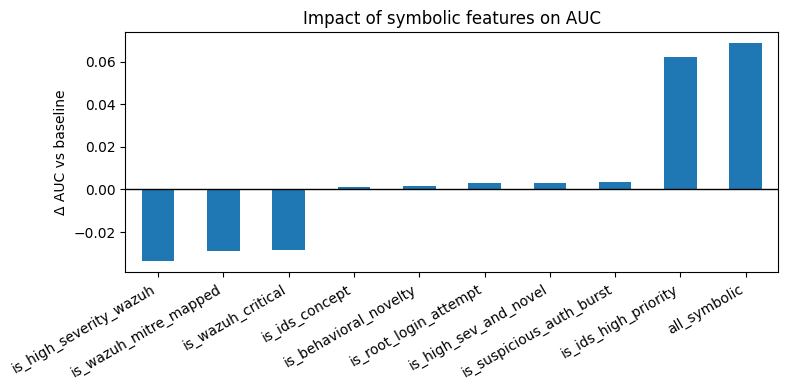

: 

In [ ]:
results_dict = {"base": res["diag_base"]}
for feat, diag in res["diag_ablation"].items():
    results_dict[feat] = diag
results_dict["all_symbolic"] = res["diag_sym_all"]

# impact of symbolic features on AUC (delta AUC over all alerts)
plot_symbolic_performance_delta(results_dict, metric="auc", out_dir=out_dir)

#### Score shift

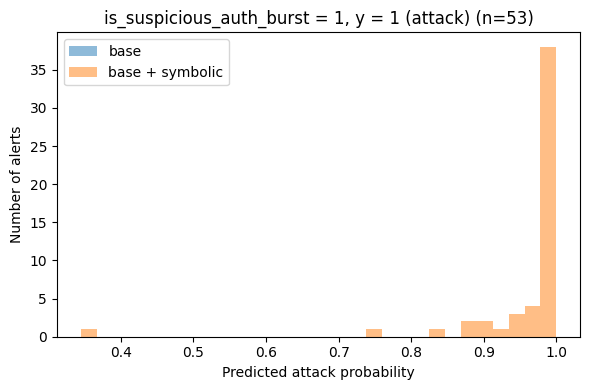

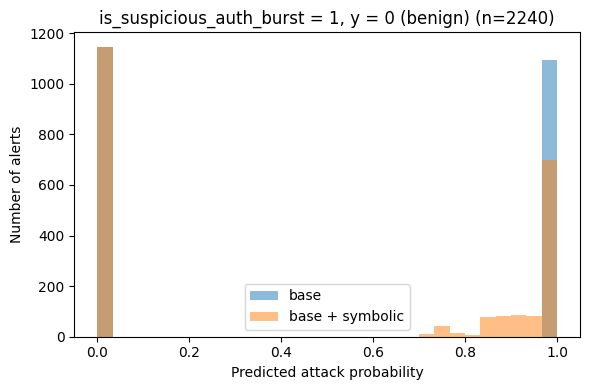

No test samples where is_root_login_attempt=1
No samples for is_behavioral_novelty=1 with y=1 (attack)


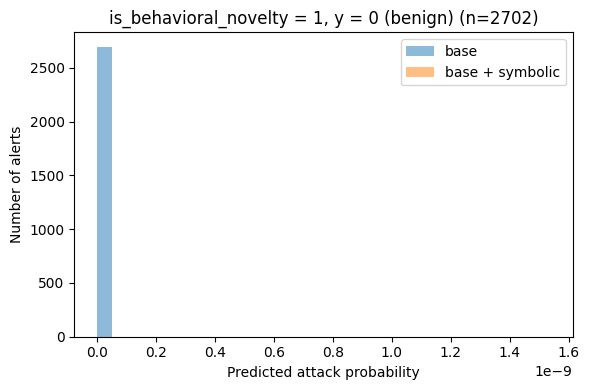

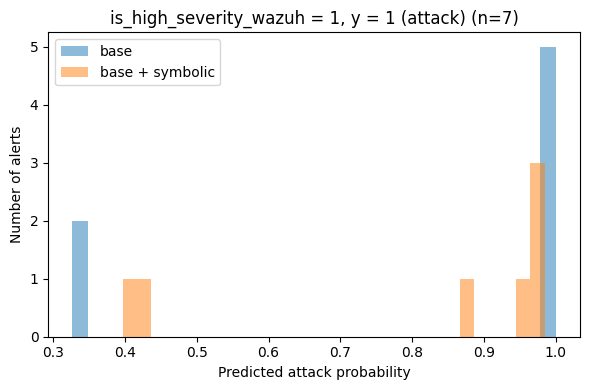

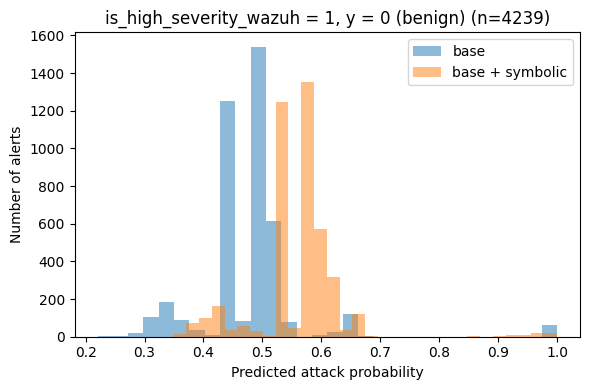

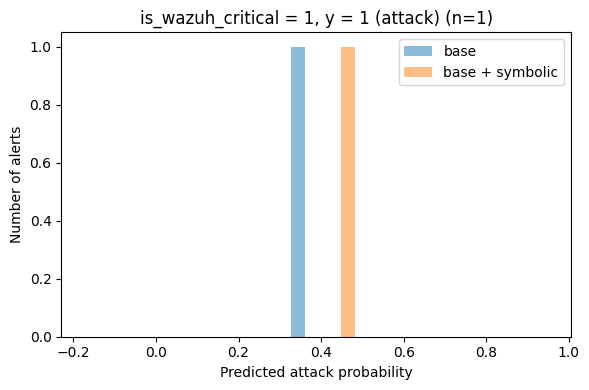

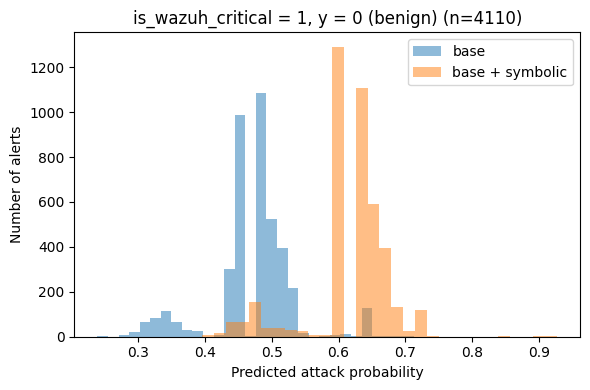

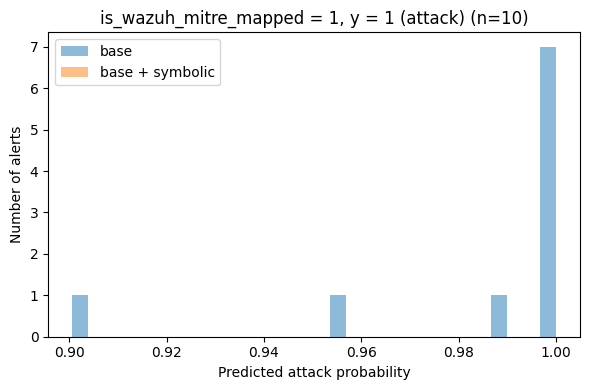

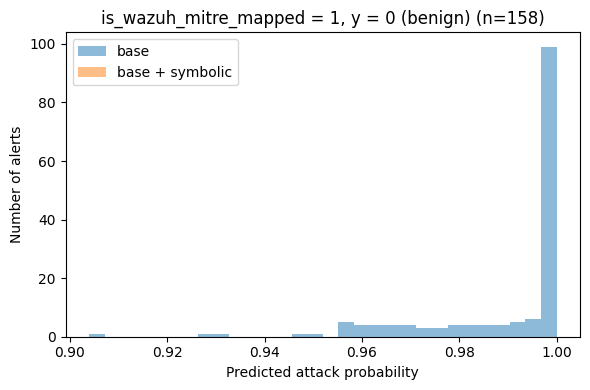

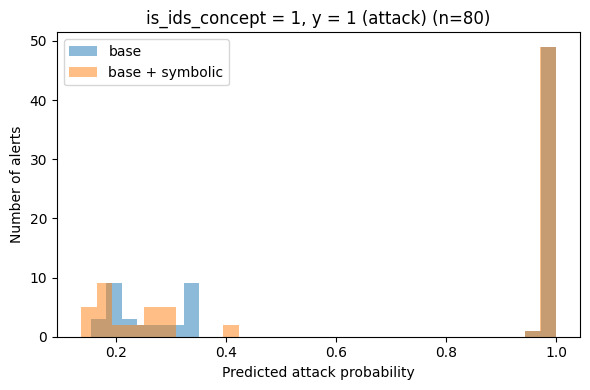

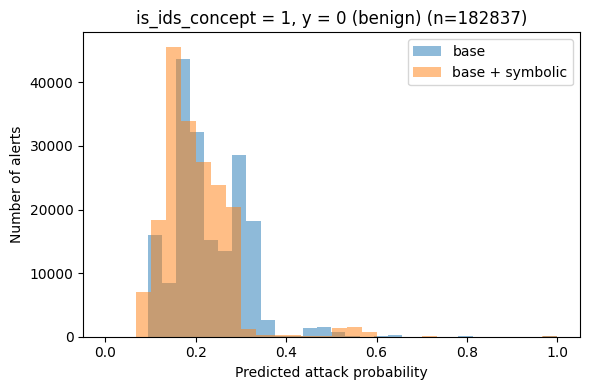

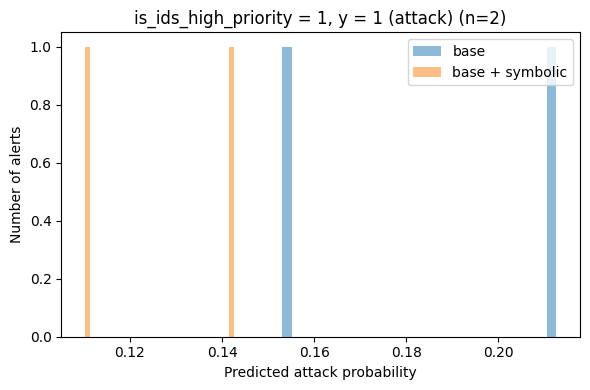

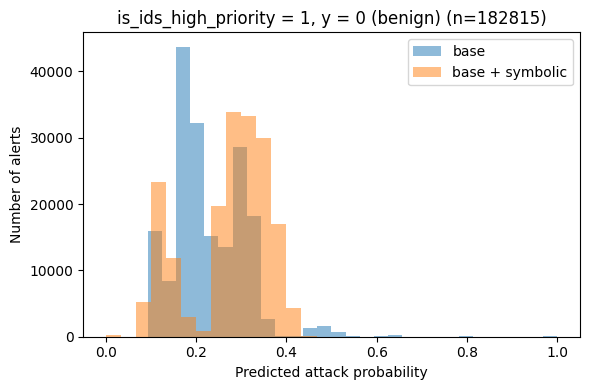

No test samples where is_high_sev_and_novel=1


: 

In [ ]:
out_dir = os.path.join(out_dir, "ablation_score_shifts")
os.makedirs(out_dir, exist_ok=True)

for f in res["sym_feats"]:
    res_feat = res["ablation"].get(f)

    if res_feat is None:
        print(f"Skipping {f} (no ablation result)")
        continue
    
    # plot score shift only for alerts where symbolic feature = 1
    # does adding a symbolic feature to the base model push predicted risk higher?
    # plot_symbolic_score_shift(
    #     X_full=res["X_full"],
    #     res_base=res["base"],
    #     res_sym=res_feat,         
    #     feature=f,
    #     out_dir=out_dir,
    #     prefix=f
    # )

    plot_symbolic_score_shift_by_label(
        X_full=res["X_full"],
        y=res["y"],
        res_base=res["base"],
        res_sym=res_feat,         
        feature=f,
        out_dir=out_dir,
        prefix=f
    )

#### FP to TN after adding symbolic feature to base

In [ ]:
rows = []

for f in res["sym_feats"]:
    res_feat = res["ablation"].get(f)
    if res_feat is None:
        continue

    stats = plot_fp_to_tn(
        X_full=res["X_full"],
        y=res["y"],
        res_base=res["base"],
        res_sym=res_feat,
        feature=f,
        threshold=0.5,
    )

    if stats is not None:
        rows.append(stats)


df_flips = pd.DataFrame(rows).sort_values(
    by=["fp_to_tn"], ascending=False
)

print(df_flips)


                    feature  n_subset  fp_to_tn  delta_fp  net_alert_change
6      is_ids_high_priority    182817      1136     -1136             -1136
5            is_ids_concept    182917       157      2609              2609
2    is_high_severity_wazuh      4246        11      2743              2743
0  is_suspicious_auth_burst      2293         0         0                -1
1     is_behavioral_novelty      2702         0         0                 0
3         is_wazuh_critical      4111         0      2826              2826
4     is_wazuh_mitre_mapped       168         0         0                 0


: 

##### Coefficient plot

In [ ]:
out_dir = os.path.join(out_dir, "ablation_coefficients")

os.makedirs(out_dir, exist_ok=True)

for feat in res["sym_feats"]:
    res_feat = res["ablation"].get(feat)

    if res_feat is None:
        print(f"Skipping {feat} (no ablation model)")
        continue

    plot_symbolic_coefficients(
        model=res_feat["model"],
        feature_names=res_feat["feature_names"],
        symbolic_features=[feat],   # plot for one feature
        out_dir=out_dir,
        prefix=feat
    )

coef_sym:  is_suspicious_auth_burst   -8.51385
dtype: float64
coef_sym:  is_root_login_attempt    0.0
dtype: float64
coef_sym:  is_behavioral_novelty   -24.414077
dtype: float64
coef_sym:  is_high_severity_wazuh   -0.157816
dtype: float64
coef_sym:  is_wazuh_critical    0.13124
dtype: float64
coef_sym:  is_wazuh_mitre_mapped    5.072561
dtype: float64
coef_sym:  is_ids_concept    1.344127
dtype: float64
coef_sym:  is_ids_high_priority   -48.109207
dtype: float64
coef_sym:  is_high_sev_and_novel    0.0
dtype: float64


: 

### Greedy search on feature subsets
##### Added more symbolic features


In [16]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)

In [ ]:
window_size = pd.Timedelta(days=1)
train_fn = make_train_fn(test_frac=0.3)

search_res = greedy_symbolic_search(
    df, window_size, train_fn=train_fn, threshold=0.5, max_k=6
)

print("Baseline metrics:", search_res["base_metrics"])
print("Chosen symbolic subset:", search_res["chosen"])
print("History:")
for row in search_res["history"]:
    print(row)

Baseline metrics: {'auc': 0.9192940840463538, 'fp': 2480, 'fn': 31, 'alerts': 2605}
Chosen symbolic subset: ['is_ids_high_priority', 'is_high_severity_wazuh', 'is_ids_concept']
History:
{'step': 1, 'added': 'is_ids_high_priority', 'chosen': ['is_ids_high_priority'], 'auc': 0.9812536772457485, 'fp': 1383, 'fn': 3, 'alerts': 1536}
{'step': 2, 'added': 'is_high_severity_wazuh', 'chosen': ['is_ids_high_priority', 'is_high_severity_wazuh'], 'auc': 0.9878150702567422, 'fp': 1388, 'fn': 3, 'alerts': 1541}
{'step': 3, 'added': 'is_ids_concept', 'chosen': ['is_ids_high_priority', 'is_high_severity_wazuh', 'is_ids_concept'], 'auc': 0.9900764263529555, 'fp': 1397, 'fn': 3, 'alerts': 1550}


: 

### Time window experiment

In [4]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["timestamp"])

In [5]:
wdays = 7
sdays = 2

wins = make_time_windows(df, window_days=wdays, step_days=sdays)
print("n_windows:", len(wins))
for i,(s,e,w) in enumerate(wins):
    print(i, s.date(), "→", e.date(), "rows", len(w), "y", w["y"].value_counts().to_dict())

n_windows: 10
0 2022-01-14 → 2022-01-21 rows 131810 y {0: 131687, 1: 123}
1 2022-01-16 → 2022-01-23 rows 94397 y {0: 94274, 1: 123}
2 2022-01-18 → 2022-01-25 rows 78952 y {0: 78787, 1: 165}
3 2022-01-20 → 2022-01-27 rows 91360 y {0: 91276, 1: 84}
4 2022-01-22 → 2022-01-29 rows 130951 y {0: 130867, 1: 84}
5 2022-01-24 → 2022-01-31 rows 177944 y {0: 177561, 1: 383}
6 2022-01-26 → 2022-02-02 rows 169705 y {0: 169381, 1: 324}
7 2022-01-28 → 2022-02-04 rows 130449 y {0: 130125, 1: 324}
8 2022-01-30 → 2022-02-06 rows 173267 y {0: 173179, 1: 88}
9 2022-02-01 → 2022-02-08 rows 231021 y {0: 230937, 1: 84}


In [6]:
print(df["y"].value_counts())
print(df["scenario"].value_counts().head())

y
0    622889
1       687
Name: count, dtype: int64
scenario
wheeler     139509
harrison    137028
wilson      132250
santos       88455
wardbeck     49584
Name: count, dtype: int64


In [7]:
print(df["y"].dtype)
print(df["y"].value_counts(dropna=False).head(20))
print(df[df["y"].isna()].head(3)[["timestamp","scenario","y"]])

int64
y
0    622889
1       687
Name: count, dtype: int64
Empty DataFrame
Columns: [timestamp, scenario, y]
Index: []


### Temporal Symbolic Feature selection

In [8]:
run_name = "hybrid_pipeline"
out_dir = f"../plots/{run_name}"
os.makedirs(out_dir, exist_ok=True)

In [24]:
config = dict(
    run_name=run_name,
    window_days=wdays,
    step_days=sdays,
    lookback_days=1,
    test_frac=0.3,
    threshold=0.5,
    use_memory=True,
    ts=datetime.now().isoformat(timespec="seconds"),
)
with open(os.path.join(out_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

all_rows = []

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")


for scenario, df_s in df.groupby("scenario"):

    span_days = (df_s["timestamp"].max() - df_s["timestamp"].min()).days
    window_days = max(1, span_days // 3)
    step_days   = window_days

    scen_dir = os.path.join(out_dir, scenario)
    os.makedirs(scen_dir, exist_ok=True)

    hist = run_windowed_symbolic_pipeline(
        df=df_s,
        window_days=window_days,
        step_days=step_days,
        lookback_days=1,
        test_frac=0.3,
        threshold=0.5,
        use_memory=True,
    )

    # save per-scenario
    with open(os.path.join(scen_dir, "history.json"), "w") as f:
        json.dump(hist, f, indent=2, default=str)

    # also collect for aggregate comparisons
    for row in hist:
        row = dict(row)
        row["scenario"] = scenario
        all_rows.append(row)

# save aggregate (easy to load/concat later)
with open(os.path.join(out_dir, "all_history.jsonl"), "w") as f:
    for row in all_rows:
        f.write(json.dumps(row, default=str) + "\n")

n_windows: 4
0 2022-01-15 → 2022-01-16 rows 4266 y {0: 4266}
1 2022-01-16 → 2022-01-17 rows 5480 y {0: 5480}
2 2022-01-17 → 2022-01-18 rows 3843 y {0: 3841, 1: 2}
3 2022-01-18 → 2022-01-19 rows 5659 y {0: 5578, 1: 81}
[pipeline] Symbolic memory enabled: True
[window 0] scenarios_in_window=['fox']

[window 0] raw df_k rows=4266 y_counts={0: 4266}
[window 0] after build_dyn_features df_used_k rows=4266 y_counts={0: 4266}
[window 1] scenarios_in_window=['fox']

[window 1] raw df_k rows=5480 y_counts={0: 5480}
[window 1] after build_dyn_features df_used_k rows=5480 y_counts={0: 5480}
[window 2] scenarios_in_window=['fox']

[window 2] raw df_k rows=3843 y_counts={0: 3841, 1: 2}
[window 2] after build_dyn_features df_used_k rows=3843 y_counts={0: 3841, 1: 2}
[window 2] Holdout failed -> switching to FP-only: Train or test has only one class. Try a different split_frac or use all scenarios.

Finished. Produced 3 history entries out of 3 window pairs.
n_windows: 4
0 2022-02-04 → 2022-02-05 row

k – index of the sliding window iteration

train_window – time range used to train + select symbolic features

active_syms – symbolic features selected in that window (kept for next window)

auc_train_base – baseline model AUC inside the training window

auc_next – performance when applied to the next window (generalization)

alerts_next – number of alerts raised in next window (threshold = 0.5)

fp_next – false positives in next window

fn_next – missed attacks in next window

In [25]:
hist_df = pd.DataFrame(hist)
hist_df.head()

,k,mode,train_window,active_syms,mem_scores,supports_k,auc_train_base,auc_next,alerts_next,fp_next,fn_next,suppressed_next_total,suppressed_next_benign,suppressed_next_attack,total_next,total_benign_next,total_attack_next,supp_rate_total,supp_rate_benign,supp_rate_attack
0,0,fp_only,2022-02-03→2022-02-04,"[is_benign_prone_entity_burst, is_ids_high_pri...","{'is_benign_prone_entity_burst': 1.0, 'is_ids_...","{'is_suspicious_auth_burst': 5, 'is_root_login...",NaN,NaN,NaN,NaN,NaN,23456,23456,0,23458,23458,0,0.999915,0.999915,NaN
1,1,fp_only,2022-02-04→2022-02-05,"[is_ids_high_priority, is_ids_concept, is_beni...","{'is_benign_prone_entity_burst': 1.85, 'is_ids...","{'is_suspicious_auth_burst': 0, 'is_root_login...",NaN,NaN,NaN,NaN,NaN,22762,22762,0,22765,22765,0,0.999868,0.999868,NaN
2,2,fp_only,2022-02-05→2022-02-06,"[is_ids_high_priority, is_ids_concept, is_beni...","{'is_benign_prone_entity_burst': 2.5725, 'is_i...","{'is_suspicious_auth_burst': 0, 'is_root_login...",NaN,NaN,NaN,NaN,NaN,22742,22742,0,22746,22746,0,0.999824,0.999824,NaN
3,3,fp_only,2022-02-06→2022-02-07,"[is_ids_concept, is_ids_high_priority, is_beni...","{'is_benign_prone_entity_burst': 3.186625, 'is...","{'is_suspicious_auth_burst': 0, 'is_root_login...",NaN,NaN,NaN,NaN,NaN,18195,18133,62,18552,18468,84,0.980757,0.981861,0.738095


#### FP Suppression rate per scenario

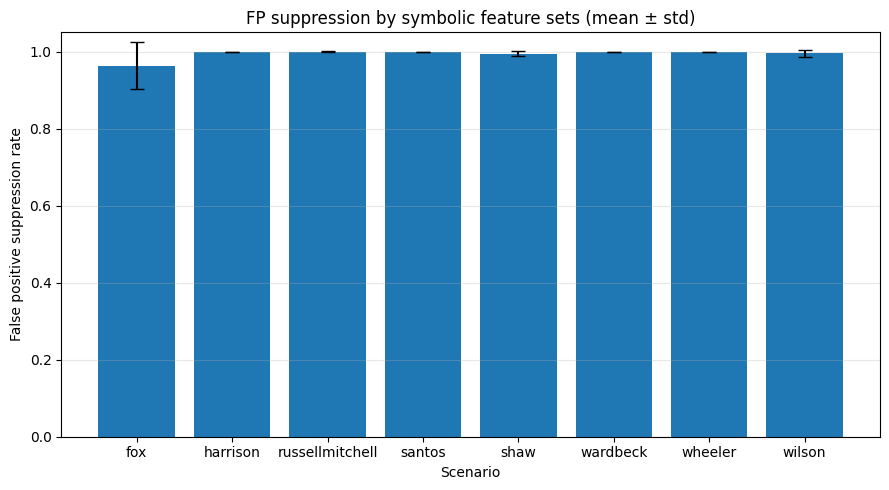

In [ ]:
from pathlib import Path

JSONL_PATH = Path(os.path.join(out_dir, "all_history.jsonl"))

rows = []
with JSONL_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

# keep only rows where benign suppression is defined
df_fp = df.dropna(subset=["supp_rate_benign"])

# ---------- aggregate ----------
fp_summary = (
    df_fp
    .groupby("scenario")["supp_rate_benign"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# ---------- plot ----------
plt.figure(figsize=(9, 5))
plt.bar(
    fp_summary["scenario"],
    fp_summary["mean"],
    yerr=fp_summary["std"],
    capsize=5
)

plt.ylim(0, 1.05)
plt.ylabel("False positive suppression rate")
plt.xlabel("Scenario")
plt.title("FP suppression by symbolic feature sets (mean ± std)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


#### Number of true attacks suppressed by scenario

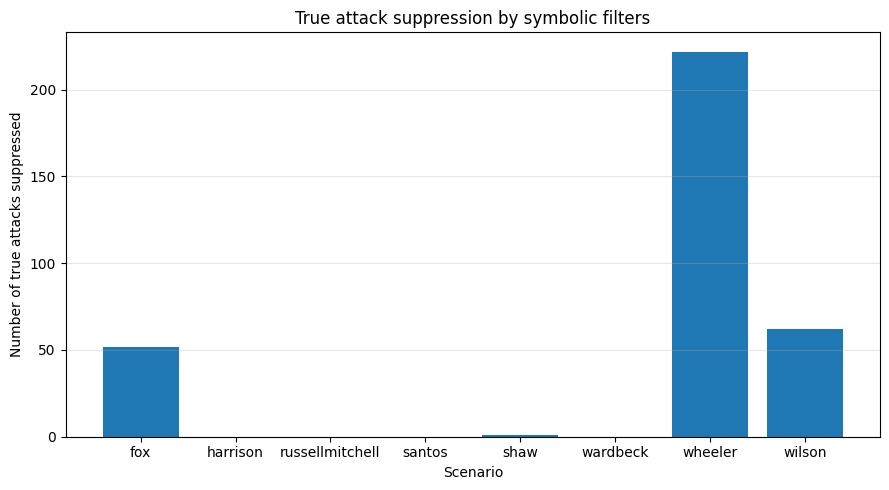

In [29]:
# keep rows where attack info exists
df_attack = df.dropna(subset=["suppressed_next_attack", "total_attack_next"])

attack_summary = (
    df_attack
    .groupby("scenario")
    .agg(
        suppressed_attacks=("suppressed_next_attack", "sum"),
        total_attacks=("total_attack_next", "sum")
    )
    .reset_index()
)

# ---------- plot ----------
plt.figure(figsize=(9, 5))
plt.bar(
    attack_summary["scenario"],
    attack_summary["suppressed_attacks"]
)

plt.ylabel("Number of true attacks suppressed")
plt.xlabel("Scenario")
plt.title("True attack suppression by symbolic filters")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### Rank symbolic features by FP suppression rate

In [9]:
d = df.copy()

# --- sanity: show available columns that matter ---
need = ["scenario","active_syms","supp_rate_benign","suppressed_next_benign","total_benign_next","total_next_benign"]
print("Has columns:", {c: (c in d.columns) for c in need})


Has columns: {'scenario': True, 'active_syms': False, 'supp_rate_benign': False, 'suppressed_next_benign': False, 'total_benign_next': False, 'total_next_benign': False}


In [ ]:
def load_history_jsonl(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    df = pd.DataFrame(rows)

    # Ensure required cols exist
    required = ["scenario", "active_syms", "suppressed_next_benign", "total_benign_next"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in history: {missing}. Found: {sorted(df.columns)}")

    # Parse numerics robustly (handles NaN strings etc.)
    for c in ["suppressed_next_benign", "total_benign_next"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Ensure active_syms is list
    def _to_list(x):
        if isinstance(x, list): return x
        if pd.isna(x): return []
        if isinstance(x, str):
            x = x.strip()
            if x.startswith("[") and x.endswith("]"):
                import ast
                try: return list(ast.literal_eval(x))
                except Exception: pass
            return [s.strip().strip("'").strip('"') for s in x.split(",") if s.strip()]
        return []

    df["active_syms"] = df["active_syms"].apply(_to_list)

    return df


def rank_fp_suppression_per_scenario(df: pd.DataFrame, topk: int = 15) -> dict:
    """
    Returns dict: scenario -> ranking DataFrame with per-feature FP suppression totals + rates
    """
    out = {}

    for scen, d in df.groupby("scenario"):
        d = d.copy()

        # Keep only windows with benign totals
        d = d.dropna(subset=["total_benign_next", "suppressed_next_benign"])
        d = d[d["total_benign_next"] > 0].copy()

        if len(d) == 0:
            out[scen] = pd.DataFrame()
            continue

        # Long form: one row per (window, active_feature)
        d = d.reset_index(drop=True)
        d["win_id"] = np.arange(len(d))

        long = (
            d[["win_id", "active_syms"]]
            .explode("active_syms")
            .dropna(subset=["active_syms"])
            .rename(columns={"active_syms": "feature"})
        )

        if len(long) == 0:
            out[scen] = pd.DataFrame()
            continue

        # Join window stats back onto (win, feature)
        long = long.merge(
            d[["win_id", "suppressed_next_benign", "total_benign_next"]],
            on="win_id",
            how="left",
        )

        # Aggregate per feature (this is the core metric you asked for)
        agg = long.groupby("feature", as_index=False).agg(
            windows_on=("win_id", "nunique"),
            suppressed_benign_total=("suppressed_next_benign", "sum"),
            total_benign_total=("total_benign_next", "sum"),
        )
        agg["supp_rate_weighted"] = agg["suppressed_benign_total"] / agg["total_benign_total"]

        # Sort by absolute FP suppression (most intuitive), tie-break by rate
        agg = agg.sort_values(
            ["suppressed_benign_total", "supp_rate_weighted"],
            ascending=False
        ).reset_index(drop=True)

        out[scen] = agg

    return out

def audit_active_sets(df):
    d = df.copy()
    d["active_set"] = d["active_syms"].apply(lambda xs: tuple(sorted(xs)) if isinstance(xs, list) else tuple())
    g = d.groupby("scenario")["active_set"].nunique().sort_values(ascending=False)
    print("Unique active sets per scenario:")
    print(g.to_string())

    # show top sets per scenario
    for scen in sorted(d["scenario"].unique()):
        sub = d[d["scenario"] == scen]
        counts = sub["active_set"].value_counts().head(5)
        print(f"\n[{scen}] top active_set counts:")
        for aset, n in counts.items():
            print(" n=", n, " size=", len(aset), " set=", list(aset)[:12], ("..." if len(aset)>12 else ""))

def audit_mem_vs_active(df):
    d = df.copy()
    d["active_set"] = d["active_syms"].apply(lambda xs: tuple(sorted(xs)))
    # how many distinct mem_scores dicts vs active sets?
    print("Distinct active sets:", d["active_set"].nunique())
    print("Distinct mem_scores dicts:", d["mem_scores"].apply(lambda x: tuple(sorted((x or {}).items()))).nunique())

def plot_fp_suppression_per_scenario(history_path: str, topk: int = 15):
    df = load_history_jsonl(history_path)
    audit_active_sets(df)   

    ranks = rank_fp_suppression_per_scenario(df, topk=topk)

    for scen, r in sorted(ranks.items()):
        
        if r is None or r.empty:
            print(f"[{scen}] no data to plot")
            continue

        audit_mem_vs_active(df[df["scenario"]==scen])


        top = r.head(topk).iloc[::-1]  # reverse for barh

        plt.figure(figsize=(11, 0.45 * len(top) + 2))
        plt.barh(top["feature"], top["suppressed_benign_total"])
        plt.xlabel("False positives suppressed (sum suppressed_next_benign when feature active)")
        plt.title(f"{scen}: FP suppression by symbolic feature (top {min(topk, len(r))})")
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Optional compact table
        display_cols = ["feature", "windows_on", "suppressed_benign_total", "supp_rate_weighted"]
        print(f"\n[{scen}] top {min(topk, len(r))}")
        print(r[display_cols].head(topk).to_string(index=False))

Unique active sets per scenario:
scenario
fox                1
harrison           1
russellmitchell    1
santos             1
shaw               1
wardbeck           1
wheeler            1
wilson             1

[fox] top active_set counts:
 n= 3  size= 6  set= ['is_benign_prone_category_burst', 'is_benign_prone_entity_burst', 'is_ids_category_malware_or_c2', 'is_ids_concept', 'is_ids_high_priority', 'is_ids_high_sev_on_benign_entity'] 

[harrison] top active_set counts:
 n= 3  size= 6  set= ['is_benign_prone_category_burst', 'is_benign_prone_entity_burst', 'is_ids_category_malware_or_c2', 'is_ids_concept', 'is_ids_high_priority', 'is_ids_high_sev_on_benign_entity'] 

[russellmitchell] top active_set counts:
 n= 2  size= 6  set= ['is_benign_prone_category_burst', 'is_benign_prone_entity_burst', 'is_ids_category_malware_or_c2', 'is_ids_concept', 'is_ids_high_priority', 'is_ids_high_sev_on_benign_entity'] 

[santos] top active_set counts:
 n= 2  size= 6  set= ['is_benign_prone_category_bu

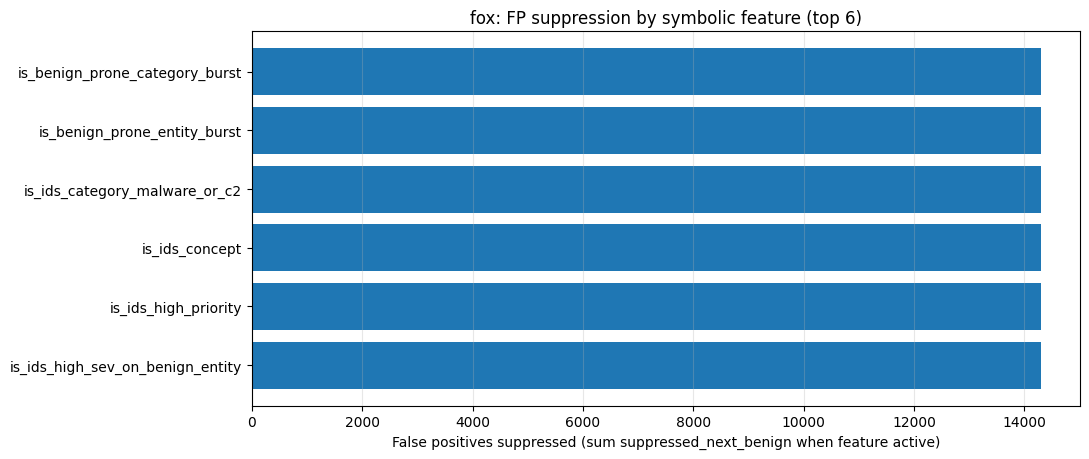


[fox] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           3                    14296            0.959527
    is_benign_prone_entity_burst           3                    14296            0.959527
   is_ids_category_malware_or_c2           3                    14296            0.959527
                  is_ids_concept           3                    14296            0.959527
            is_ids_high_priority           3                    14296            0.959527
is_ids_high_sev_on_benign_entity           3                    14296            0.959527


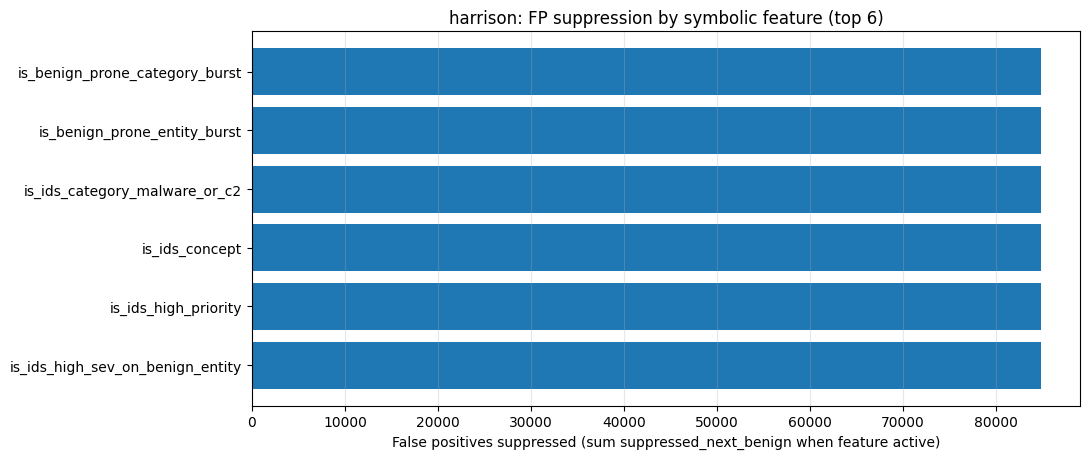


[harrison] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           3                    84773            0.999717
    is_benign_prone_entity_burst           3                    84773            0.999717
   is_ids_category_malware_or_c2           3                    84773            0.999717
                  is_ids_concept           3                    84773            0.999717
            is_ids_high_priority           3                    84773            0.999717
is_ids_high_sev_on_benign_entity           3                    84773            0.999717


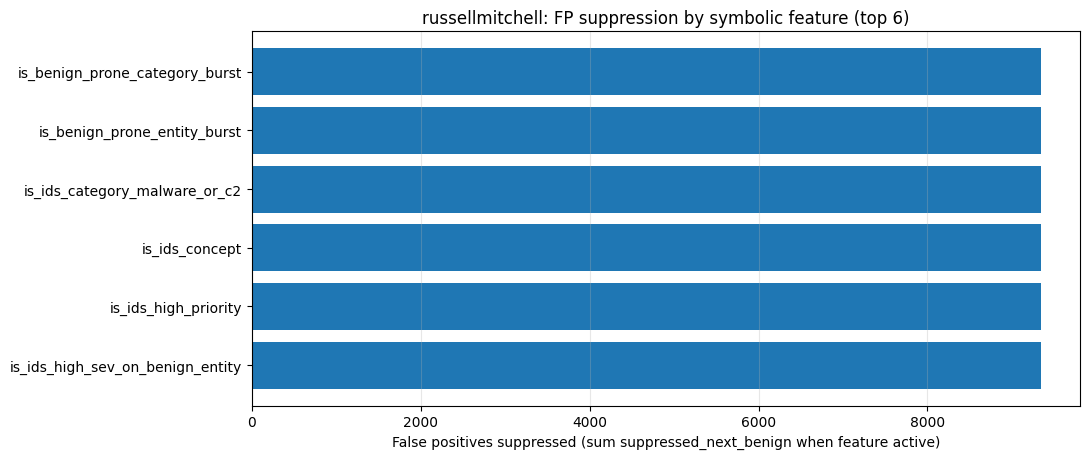


[russellmitchell] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           2                     9340            0.999465
    is_benign_prone_entity_burst           2                     9340            0.999465
   is_ids_category_malware_or_c2           2                     9340            0.999465
                  is_ids_concept           2                     9340            0.999465
            is_ids_high_priority           2                     9340            0.999465
is_ids_high_sev_on_benign_entity           2                     9340            0.999465


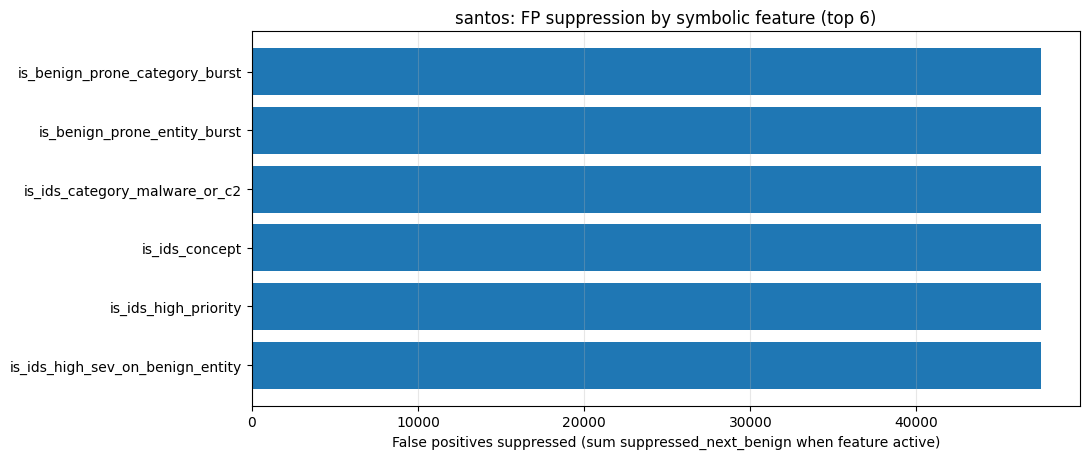


[santos] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           2                    47470            0.999768
    is_benign_prone_entity_burst           2                    47470            0.999768
   is_ids_category_malware_or_c2           2                    47470            0.999768
                  is_ids_concept           2                    47470            0.999768
            is_ids_high_priority           2                    47470            0.999768
is_ids_high_sev_on_benign_entity           2                    47470            0.999768


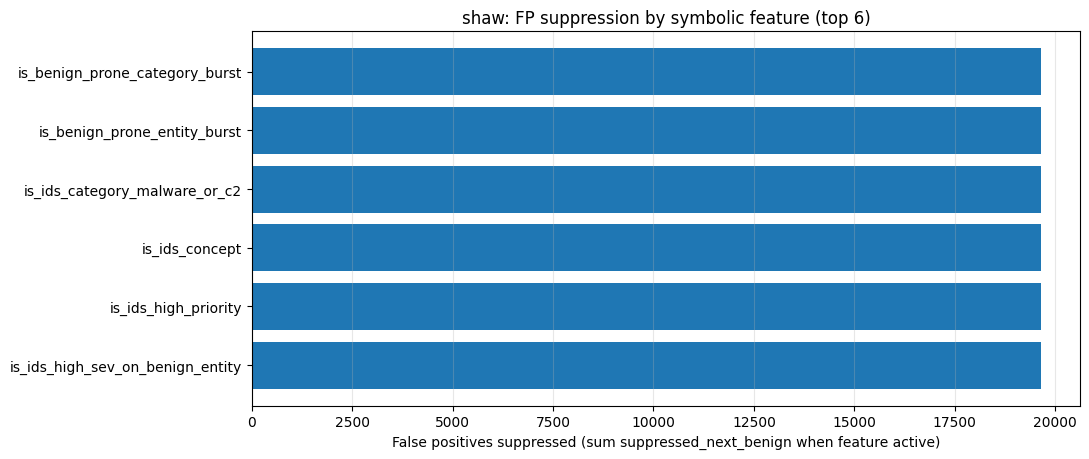


[shaw] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           4                    19640            0.995388
    is_benign_prone_entity_burst           4                    19640            0.995388
   is_ids_category_malware_or_c2           4                    19640            0.995388
                  is_ids_concept           4                    19640            0.995388
            is_ids_high_priority           4                    19640            0.995388
is_ids_high_sev_on_benign_entity           4                    19640            0.995388


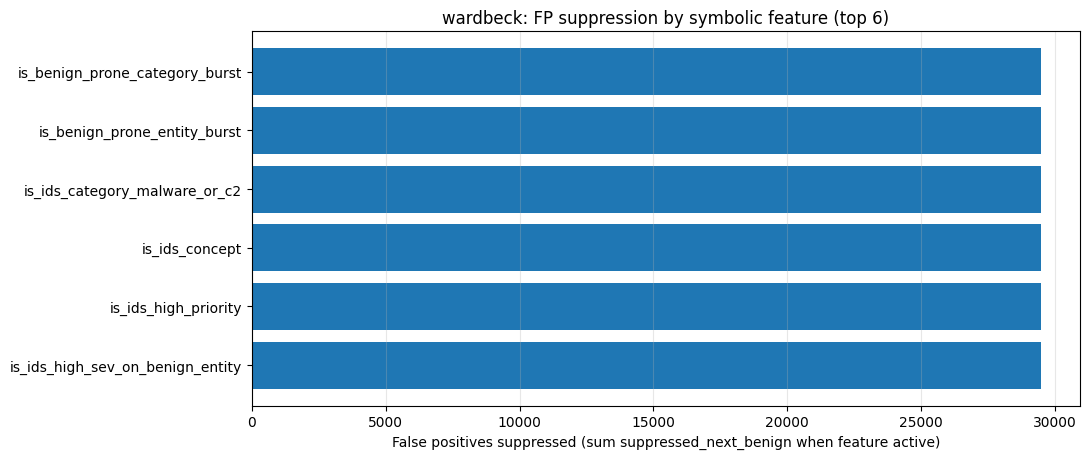


[wardbeck] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           3                    29475            0.999424
    is_benign_prone_entity_burst           3                    29475            0.999424
   is_ids_category_malware_or_c2           3                    29475            0.999424
                  is_ids_concept           3                    29475            0.999424
            is_ids_high_priority           3                    29475            0.999424
is_ids_high_sev_on_benign_entity           3                    29475            0.999424


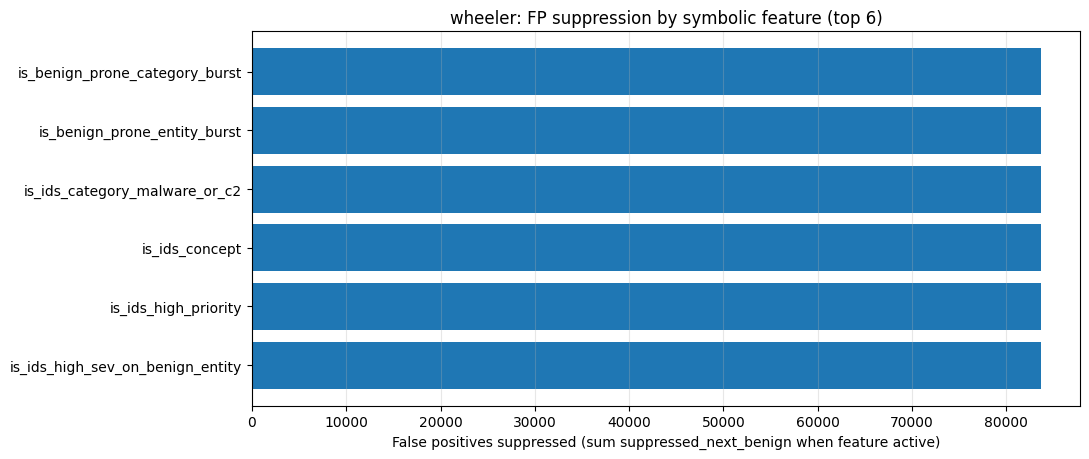


[wheeler] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           3                    83626            0.999785
    is_benign_prone_entity_burst           3                    83626            0.999785
   is_ids_category_malware_or_c2           3                    83626            0.999785
                  is_ids_concept           3                    83626            0.999785
            is_ids_high_priority           3                    83626            0.999785
is_ids_high_sev_on_benign_entity           3                    83626            0.999785


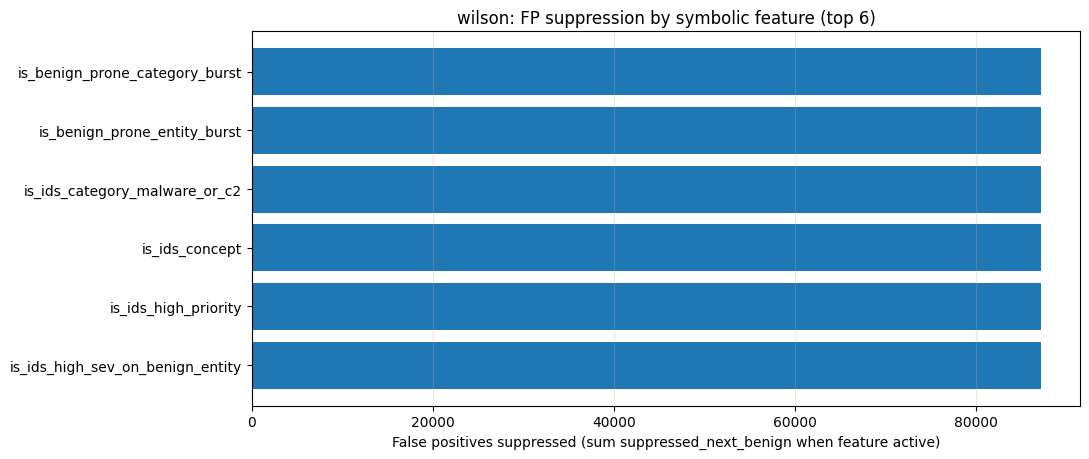


[wilson] top 6
                         feature  windows_on  suppressed_benign_total  supp_rate_weighted
  is_benign_prone_category_burst           4                    87093            0.996066
    is_benign_prone_entity_burst           4                    87093            0.996066
   is_ids_category_malware_or_c2           4                    87093            0.996066
                  is_ids_concept           4                    87093            0.996066
            is_ids_high_priority           4                    87093            0.996066
is_ids_high_sev_on_benign_entity           4                    87093            0.996066


In [17]:
plot_fp_suppression_per_scenario(os.path.join(out_dir, "all_history.jsonl"), topk=15)

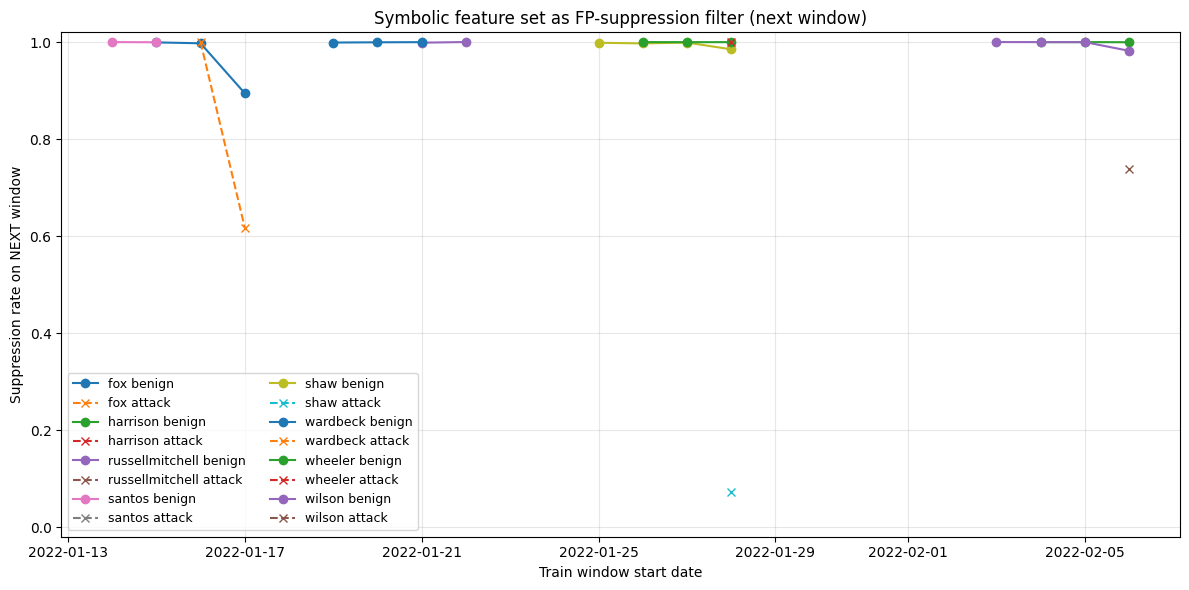

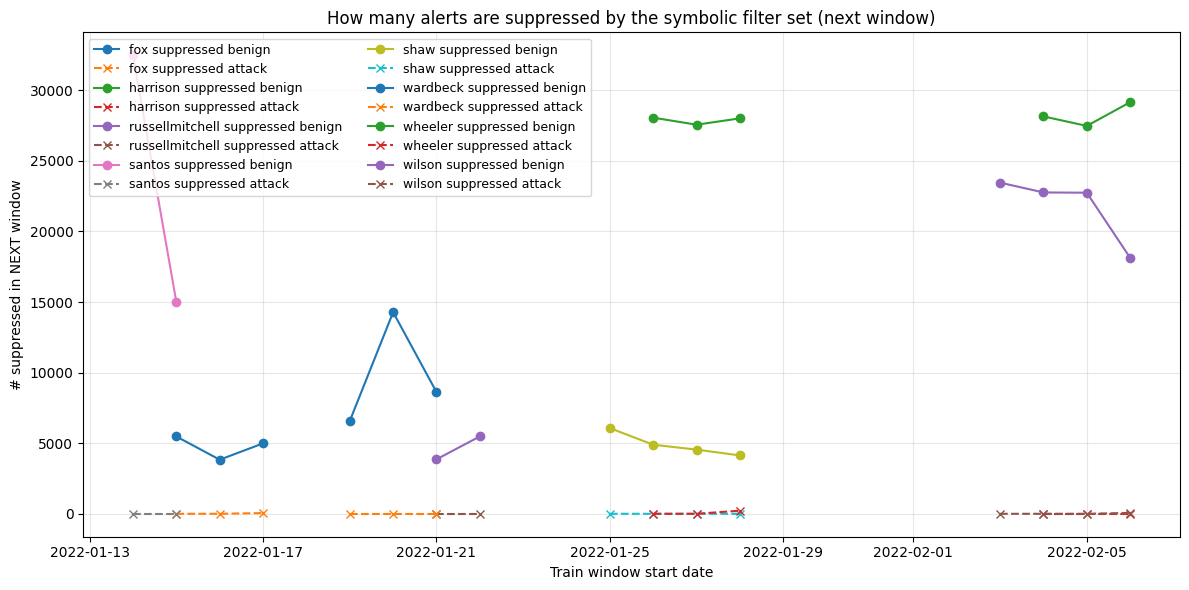

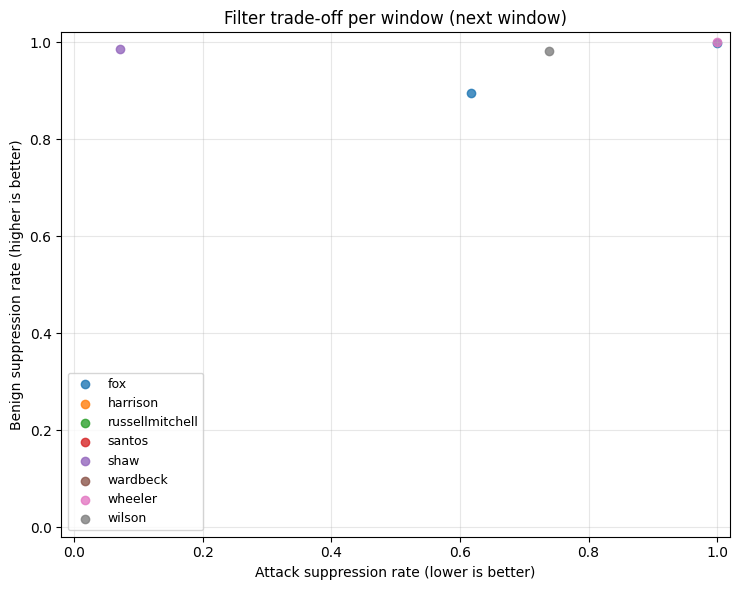

In [26]:
from pathlib import Path

JSONL_PATH = Path(os.path.join(out_dir, "all_history.jsonl"))

# -------- load jsonl --------
rows = []
with JSONL_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# -------- parse dates / sort --------
arrow = "→"
df["train_start"] = pd.to_datetime(df["train_window"].str.split(arrow).str[0], errors="coerce")
df["train_end"]   = pd.to_datetime(df["train_window"].str.split(arrow).str[1], errors="coerce")
df = df.sort_values(["scenario", "train_start", "k"]).reset_index(drop=True)

# Ensure columns exist (older runs may not have them)
for col in [
    "supp_rate_total","supp_rate_benign","supp_rate_attack",
    "suppressed_next_total","suppressed_next_benign","suppressed_next_attack",
    "total_next","total_benign_next","total_attack_next"
]:
    if col not in df.columns:
        df[col] = pd.NA

# -------- Plot 1: suppression rate (benign vs attack) --------
plt.figure(figsize=(12, 6))
for scenario, g in df.groupby("scenario"):
    plt.plot(g["train_start"], g["supp_rate_benign"], marker="o", linestyle="-", label=f"{scenario} benign")
    plt.plot(g["train_start"], g["supp_rate_attack"], marker="x", linestyle="--", label=f"{scenario} attack")
plt.ylim(-0.02, 1.02)
plt.xlabel("Train window start date")
plt.ylabel("Suppression rate on NEXT window")
plt.title("Symbolic feature set as FP-suppression filter (next window)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# -------- Plot 2: absolute suppressed counts (benign vs attack) --------
plt.figure(figsize=(12, 6))
for scenario, g in df.groupby("scenario"):
    plt.plot(g["train_start"], g["suppressed_next_benign"], marker="o", linestyle="-", label=f"{scenario} suppressed benign")
    plt.plot(g["train_start"], g["suppressed_next_attack"], marker="x", linestyle="--", label=f"{scenario} suppressed attack")
plt.xlabel("Train window start date")
plt.ylabel("# suppressed in NEXT window")
plt.title("How many alerts are suppressed by the symbolic filter set (next window)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# -------- Plot 3: trade-off scatter (benign suppressed vs attack suppressed) --------
# Each point = one window, colored by scenario. Good points are top-left (high benign, low attack).
plt.figure(figsize=(7.5, 6))
for scenario, g in df.groupby("scenario"):
    plt.scatter(g["supp_rate_attack"], g["supp_rate_benign"], label=scenario, alpha=0.8)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.xlabel("Attack suppression rate (lower is better)")
plt.ylabel("Benign suppression rate (higher is better)")
plt.title("Filter trade-off per window (next window)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
def attacks_per_week_report(df, ts_col="timestamp", y_col="y", scenario_col=None, tz="UTC"):
    """
    Returns a weekly report of attacks/benign counts.
    - df: labeled dataframe with timestamp + y (0/1)
    - scenario_col: if provided, includes per-scenario weekly breakdown too
    """
    d = df.copy()

    # timestamps
    d[ts_col] = pd.to_datetime(d[ts_col], utc=True, errors="coerce")
    d = d.dropna(subset=[ts_col])

    # labels
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")
    d = d.dropna(subset=[y_col])
    d[y_col] = d[y_col].astype(int)

    # week buckets (Mon-start; change 'W-SUN' if you want Sunday start)
    d["week"] = d[ts_col].dt.to_period("W-MON").dt.start_time

    # overall weekly counts
    weekly = (
        d.groupby("week")[y_col]
        .agg(
            n_total="count",
            n_attacks="sum",
        )
        .reset_index()
    )
    weekly["n_benign"] = weekly["n_total"] - weekly["n_attacks"]
    weekly["attack_rate"] = weekly["n_attacks"] / weekly["n_total"]
    weekly["has_both_classes"] = (weekly["n_attacks"] > 0) & (weekly["n_benign"] > 0)

    # optional per-scenario breakdown
    weekly_by_scenario = None
    if scenario_col is not None and scenario_col in d.columns:
        weekly_by_scenario = (
            d.groupby([scenario_col, "week"])[y_col]
            .agg(n_total="count", n_attacks="sum")
            .reset_index()
        )
        weekly_by_scenario["n_benign"] = weekly_by_scenario["n_total"] - weekly_by_scenario["n_attacks"]
        weekly_by_scenario["attack_rate"] = weekly_by_scenario["n_attacks"] / weekly_by_scenario["n_total"]
        weekly_by_scenario["has_both_classes"] = (
            (weekly_by_scenario["n_attacks"] > 0) & (weekly_by_scenario["n_benign"] > 0)
        )

    summary = {
        "n_weeks": int(len(weekly)),
        "weeks_with_attacks": int((weekly["n_attacks"] > 0).sum()),
        "weeks_with_both_classes": int(weekly["has_both_classes"].sum()),
        "weeks_single_class": int((~weekly["has_both_classes"]).sum()),
        "min_attacks_per_week": int(weekly["n_attacks"].min()) if len(weekly) else 0,
        "median_attacks_per_week": float(weekly["n_attacks"].median()) if len(weekly) else 0.0,
        "max_attacks_per_week": int(weekly["n_attacks"].max()) if len(weekly) else 0,
    }

    return weekly.sort_values("week"), weekly_by_scenario, summary


: 

In [ ]:
df = pd.read_csv("../data/ait_ads/combined_ait_labeled.csv", low_memory=False)

weekly, weekly_scn, summary = attacks_per_week_report(df, scenario_col="scenario")
print(summary)
display(weekly.head(10))

# If you want to see which weeks are single-class:
display(weekly[~weekly["has_both_classes"]].head(20))


{'n_weeks': 5, 'weeks_with_attacks': 5, 'weeks_with_both_classes': 5, 'weeks_single_class': 0, 'min_attacks_per_week': 42, 'median_attacks_per_week': 84.0, 'max_attacks_per_week': 324}


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_89691/493214278.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  d["week"] = d[ts_col].dt.to_period("W-MON").dt.start_time


,week,n_total,n_attacks,n_benign,attack_rate,has_both_classes
0,2022-01-11,102044,42,102002,0.000412,True
1,2022-01-18,78944,165,78779,0.002090,True
2,2022-01-25,173310,324,172986,0.001869,True
3,2022-02-01,231021,84,230937,0.000364,True
4,2022-02-08,38257,72,38185,0.001882,True


,week,n_total,n_attacks,n_benign,attack_rate,has_both_classes


: 